# Fig 5 — Validation archetype classifier, survival, and prognostic models

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('validation_and_discovery', 'fig5')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

import math
import re

import matplotlib as mpl
import seaborn as sns

from dlbcl.dlbcl_io import DISCOVERY_PATIENTS, elastic_net_classifier, rel_path, log_wrote, log_saved
from dlbcl.validation_classifications import load_case_classification_validation
from dlbcl.validation_classifier_survival import BASELINE_CORE, run_classifier_os_benchmark

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "DejaVu Sans"
RUN_OOF_BOOTSTRAP_CI = True
OOF_BOOTSTRAP_N = 2000
OOF_BOOTSTRAP_SEED = 0
RUN_TRAINING_ROC = False
case_cc = load_case_classification_validation(adata.uns["validation_cohort"], pred)

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, write_supplementary_table, rel_path
import dlbcl.validation_figures as vf

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "DejaVu Sans"
from dlbcl.km_sensitivity import (
    DISCOVERY_ARCHETYPE_OUTLIERS,
    DISCOVERY_ENDPOINTS,
    VALIDATION_EXCLUDE_LOCATIONS,
    build_discovery_km_survival_table,
    discovery_to_km_frame,
    exclude_locations,
    exclude_patients,
    load_validation_survival_table,
)


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/fig5


## Validation immune-archetype classifier
Trains and evaluates an elastic-net multinomial classifier that predicts the immune
archetype (`abundance_cluster_30`) from bulk gene expression, with nested
cross-validation.
| Figure | Section |
|--------|---------|
| (metrics) | Nested-CV balanced accuracy + macro AUROC (`figures/fig5/nestedcv_performance_summary.*`) |
| S2H | Classifier confusion matrix |
**Config toggles:** `RUN_OOF_BOOTSTRAP_CI` (bootstrap 95% CIs on OOF metrics), `RUN_TRAINING_ROC` (exploratory in-sample ROC, off by default).
**Requires** embedded archetype labels in `adata.uns`.
**Data:** `data/DLBCL_location_2026.h5ad` — set `DLBCL_DATA_DIR` to override the data root.

## Load data

In [2]:
adata = sc.read_h5ad(ADATA_PATH)

mask = (
    adata.obs["patient_id"].isin(PATIENT_SUBSET)
    & (adata.obs["filtering_status"] == "Unfiltered")
)
adata = adata[mask].copy()
gc.collect()

print(f"Cells: {adata.n_obs:,} | patients: {adata.obs['patient_id'].nunique()}")


Cells: 1,192,844 | patients: 64


## Load archetype assignments (from processed archetype assignments)

In [3]:
# Immune-archetype assignments from embedded AnnData (uns).
from dlbcl.dlbcl_io import ensure_discovery_archetypes

arch_df = ensure_discovery_archetypes(adata, _paths)
print(
    "Loaded archetypes for",
    arch_df["abundance_cluster_30"].notna().sum(),
    "patients from adata.uns",
)


Loaded archetypes for 64 patients from adata.uns


## Immune-archetype classifier — nested cross-validation
Elastic-net multinomial classifier of `abundance_cluster_30` from bulk expression.
Run the previous cell first (builds `X_np`, `y_np`, and labels). The code cell below runs nested CV, refits the final model, and writes outputs to `figures/fig5/`.
**Manuscript metrics:** nested-CV balanced accuracy and out-of-fold (OOF) macro AUROC (see performance summary cell). Set `RUN_OOF_BOOTSTRAP_CI = True` in Config for stratified bootstrap 95% CIs on those OOF metrics.

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# =========================================================
# Build X / y from your current adata.uns structure
# =========================================================

cluster_dict = adata.uns["abundance_cluster_30"]
expr = adata.uns["gene_expression"].copy()

# -----------------------------
# Labels: patient_id -> class
# -----------------------------
y_raw = pd.Series(cluster_dict, name="cluster_assignment")

# make sure patient IDs are strings
y_raw.index = y_raw.index.astype(str)

# if values are numpy ints etc, normalize them
y_raw = y_raw.astype(int)

# -----------------------------
# Expression: expected genes x patients
# -----------------------------
# If Probe is a normal column rather than index, move it into the index
if "Probe" in expr.columns:
    expr = expr.set_index("Probe")

expr.index = expr.index.astype(str)       # gene names
expr.columns = expr.columns.astype(str)   # patient IDs

# -----------------------------
# Intersect patients
# -----------------------------
common_patients = [pid for pid in expr.columns if pid in y_raw.index]

if len(common_patients) == 0:
    raise ValueError(
        "No overlapping patient IDs between adata.uns['gene_expression'] columns "
        "and adata.uns['abundance_cluster_30'] keys."
    )

print(f"Overlapping patients: {len(common_patients)}")

# -----------------------------
# Rebuild X as patients x genes
# -----------------------------
X = expr[common_patients].T.copy()
y_raw = y_raw.loc[common_patients].copy()

# -----------------------------
# QC on features
# -----------------------------
# drop genes with any NA
na_mask = X.notna().all(axis=0)
X = X.loc[:, na_mask]

# drop zero-variance genes
var_mask = X.var(axis=0) > 0
X = X.loc[:, var_mask]

# optional: ensure unique gene names
if not X.columns.is_unique:
    print("Warning: duplicate gene names found. Aggregating duplicates by mean.")
    X = X.groupby(level=0, axis=1).mean()

# final checks
print("X shape:", X.shape)
print("y shape:", y_raw.shape)
print("Class counts:")
print(y_raw.value_counts().sort_index())

# -----------------------------
# Encode labels for sklearn
# -----------------------------
le = LabelEncoder()
y_np = le.fit_transform(y_raw.values)
class_names = le.classes_

X_np = X.to_numpy(dtype=float)

print("\nEncoded classes:")
for i, c in enumerate(class_names):
    print(f"{i} -> {c}")


Overlapping patients: 64
X shape: (64, 797)
y shape: (64,)
Class counts:
cluster_assignment
1    29
2    15
3    20
Name: count, dtype: int64

Encoded classes:
0 -> 1
1 -> 2
2 -> 3


In [5]:
# Nested CV: elastic-net multinomial classifier for immune archetype (abundance_cluster_30).
#
# Workflow
#   1. Outer CV — tune C and l1_ratio on inner folds; score each held-out patient once (OOF).
#   2. Summarize balanced accuracy, macro F1, log loss, and aggregated confusion matrix.
#   3. Pick final hyperparameters (highest mean inner-CV score across outer folds).
#   4. Refit on all patients; save model, coefficients, and optional bootstrap gene stability.
#
# Requires the previous cell: X_np, y_np, X, y_raw, class_names, le.
# Writes CSVs and cluster_assignment_elasticnet_model.joblib under figures/fig5/elasticnet/.
#
# Speed / resource knobs (edit in Controls below):
#   N_JOBS — parallel workers (-1 = all cores; use 4 on shared servers)
#   RUN_BOOTSTRAP=False — skip bootstrap stability (fastest)
#   BOOTSTRAPS — fewer iterations (e.g. 200) for quicker stability estimates
#   USE_HALVING=True — faster inner search via HalvingGridSearchCV when supported
#   RUN_OOF_BOOTSTRAP_CI=True (in Config) — bootstrap 95% CIs on OOF metrics

import numpy as np
import pandas as pd
from pathlib import Path

ELASTICNET_DIR = Path(FIG_DIR) / "elasticnet"
ELASTICNET_DIR.mkdir(parents=True, exist_ok=True)
OUTDIR = ELASTICNET_DIR
from dataclasses import dataclass
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)
from sklearn.utils import check_random_state

# -----------------------------
# Controls
# -----------------------------
OUTER_SPLITS = 5
INNER_SPLITS = 4
RANDOM_SEED = 0

# Hyperparameter search grid (keep modest — multinomial elastic net is slow)
C_GRID = np.logspace(-3, 1, 9)              # 1e-3 .. 10
L1R_GRID = [0.1, 0.3, 0.5, 0.7, 0.9]

N_JOBS = -1   # sklearn parallel jobs; -1 uses all cores

# Numerical stability for probs
EPS = 1e-12

# Bootstrap stability selection (optional; set RUN_BOOTSTRAP=False to skip)
RUN_BOOTSTRAP = True
BOOTSTRAPS = 300
STAB_FREQ_TH = 0.7               # report genes selected in >= this fraction of bootstraps
STAB_COEF_MIN_ABS = 0.02         # |coef| threshold to count a gene as "selected"

# Gene panel
TOP_UP = 15
TOP_DOWN = 15

MAX_ITER_INNER = 12000           # saga iterations during inner CV search
MAX_ITER_FINAL = 30000
TOL = 1e-3

# -----------------------------
# Inner CV search backend (HalvingGridSearchCV is faster when USE_HALVING=True)
# -----------------------------
USE_HALVING = False
try:
    if USE_HALVING:
        from sklearn.experimental import enable_halving_search_cv  # noqa: F401
        from sklearn.model_selection import HalvingGridSearchCV
        _HAS_HALVING = True
    else:
        _HAS_HALVING = False
except Exception:
    _HAS_HALVING = False

from sklearn.model_selection import GridSearchCV

# -----------------------------
# Helpers
# -----------------------------
def _make_search(estimator, param_grid, inner_cv):
    """
    Build an inner CV search object.
    Uses HalvingGridSearchCV if available, else GridSearchCV.
    """
    if _HAS_HALVING:
        # resource='clf__max_iter' is a safe progressive resource for saga
        return HalvingGridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring="balanced_accuracy",
            cv=inner_cv,
                    refit=True,
            factor=3,
            resource="clf__max_iter",
            max_resources=MAX_ITER_INNER,
            min_resources=max(1000, MAX_ITER_INNER // 9),
            aggressive_elimination=True,
            error_score="raise",
        )
    return GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
            refit=True,
        error_score="raise",
    )

def _entropy_norm(probs, eps=EPS):
    K = probs.shape[1]
    p = np.clip(probs, eps, 1.0)
    ent = -(p * np.log(p)).sum(axis=1) / np.log(K)
    return ent

def _stratified_bootstrap_indices(y_vec, rng):
    y_vec = np.asarray(y_vec)
    idxs = []
    for c in np.unique(y_vec):
        cls_idx = np.where(y_vec == c)[0]
        idxs.append(rng.choice(cls_idx, size=len(cls_idx), replace=True))
    boot = np.concatenate(idxs)
    rng.shuffle(boot)
    return boot

def _selected_gene_mask_from_clf(clf, coef_min_abs=0.0):
    c = clf.coef_
    if coef_min_abs <= 0:
        return (np.abs(c) > 0).any(axis=0)
    return (np.abs(c) >= coef_min_abs).any(axis=0)

def _safe_reset_index_as_gene(df):
    """Move the index to a 'gene' column for CSV export."""
    out = df.copy()
    out.insert(0, "gene", out.index.astype(str))
    out = out.reset_index(drop=True)
    return out

# -----------------------------
# Nested CV loop (outer folds)
# -----------------------------
base_clf = elastic_net_classifier(
    class_weight="balanced",
    max_iter=MAX_ITER_INNER,
    tol=TOL,
    random_state=RANDOM_SEED
)

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", base_clf),
])

param_grid = {"clf__C": C_GRID, "clf__l1_ratio": L1R_GRID}
outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=1)
inner_cv = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=2)

outer_rows = []
conf_mats = []
best_params_per_fold = []
best_inner_score_per_fold = []

K = len(class_names)
oof_pred = np.full((len(y_np), K), np.nan, dtype=float)
oof_pred_label = np.full((len(y_np),), -1, dtype=int)

for fold, (tr, te) in enumerate(outer_cv.split(X_np, y_np), start=1):
    search = _make_search(pipe, param_grid, inner_cv)
    search.fit(X_np[tr], y_np[tr])

    y_pred = search.predict(X_np[te])
    y_prob = search.predict_proba(X_np[te])

    oof_pred[te] = y_prob
    oof_pred_label[te] = y_pred

    bal_acc = balanced_accuracy_score(y_np[te], y_pred)
    macro_f1 = f1_score(y_np[te], y_pred, average="macro")
    cm = confusion_matrix(y_np[te], y_pred, labels=np.arange(K))
    conf_mats.append(cm)

    # Multi-class log loss on held-out fold (lower = better probability calibration)
    ll = log_loss(y_np[te], np.clip(y_prob, EPS, 1 - EPS), labels=np.arange(K))

    y_bin_te = label_binarize(y_np[te], classes=np.arange(K))
    fold_macro_auroc = float(
        roc_auc_score(y_bin_te, y_prob, average="macro", multi_class="ovr")
    )

    best_params_per_fold.append(search.best_params_)
    best_inner_score_per_fold.append(float(getattr(search, "best_score_", np.nan)))

    outer_rows.append({
        "outer_fold": fold,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "macro_auroc": fold_macro_auroc,
        "log_loss": ll,
        "best_inner_balacc": float(getattr(search, "best_score_", np.nan)),
        "best_C": search.best_params_["clf__C"],
        "best_l1_ratio": search.best_params_["clf__l1_ratio"],
        "n_test": len(te),
    })

outer_df = pd.DataFrame(outer_rows)
print("\nNested CV performance (outer folds):")
display(outer_df)

print("\nSummary (mean ± sd):")
display(
    outer_df[["balanced_accuracy", "macro_f1", "macro_auroc", "log_loss"]]
    .agg(["mean", "std"])
    .round(4)
)

cm_sum = np.sum(conf_mats, axis=0)
cm_df = pd.DataFrame(cm_sum, index=[f"true_{c}" for c in class_names], columns=[f"pred_{c}" for c in class_names])
print("\nAggregated confusion matrix (sum over outer folds):")
display(cm_df)

# Out-of-fold (OOF) predictions and uncertainty per patient
conf = np.nanmax(oof_pred, axis=1)
entropy = _entropy_norm(oof_pred)

oof_df = pd.DataFrame({
    "patient_id": X.index.astype(str),
    "true_cluster": y_raw.values,
    "pred_cluster": [class_names[i] if i >= 0 else None for i in oof_pred_label],
    "confidence_maxprob": conf,
    "entropy_norm": entropy,
})

for i, c in enumerate(class_names):
    oof_df[f"prob_{c}"] = oof_pred[:, i]

print("\nOOF uncertainty snapshot (lowest confidence):")
display(oof_df.sort_values("confidence_maxprob").head(10))


print("\nOOF uncertainty snapshot (highest entropy):")
display(oof_df.sort_values("entropy_norm", ascending=False).head(10))

# -----------------------------
# Optional: bootstrap 95% CIs on pooled OOF metrics
# -----------------------------
oof_bootstrap_ci = None
if RUN_OOF_BOOTSTRAP_CI:
    rng_ci = check_random_state(OOF_BOOTSTRAP_SEED)
    y_bin_full = label_binarize(y_np, classes=np.arange(K))
    bal_boot, auroc_boot = [], []

    for _ in range(OOF_BOOTSTRAP_N):
        idx = _stratified_bootstrap_indices(y_np, rng_ci)
        bal_boot.append(balanced_accuracy_score(y_np[idx], oof_pred_label[idx]))
        auroc_boot.append(
            roc_auc_score(
                y_bin_full[idx],
                oof_pred[idx],
                average="macro",
                multi_class="ovr",
            )
        )

    oof_bootstrap_ci = pd.DataFrame(
        {
            "metric": ["balanced_accuracy_oof", "macro_AUROC_oof"],
            "estimate": [np.mean(bal_boot), np.mean(auroc_boot)],
            "ci_lo": [np.percentile(bal_boot, 2.5), np.percentile(auroc_boot, 2.5)],
            "ci_hi": [np.percentile(bal_boot, 97.5), np.percentile(auroc_boot, 97.5)],
            "n_bootstrap": OOF_BOOTSTRAP_N,
            "method": "stratified_bootstrap_oof",
        }
    )
    print(
        f"\nOOF bootstrap CIs (B={OOF_BOOTSTRAP_N}, stratified):"
    )
    display(oof_bootstrap_ci.round(4))
    oof_bootstrap_ci.to_csv(
        OUTDIR / "location_elasticnet_oof_bootstrap_ci.csv", index=False
    )

# -----------------------------
# Final hyperparameters for refit
# -----------------------------
# Use the (C, l1_ratio) pair with the highest mean inner-CV score across outer folds.
param_df = pd.DataFrame(best_params_per_fold)
param_df["best_inner_balacc"] = best_inner_score_per_fold

# group by parameter pair and average the inner score across folds where it won
gb = param_df.groupby(["clf__C", "clf__l1_ratio"], as_index=False)["best_inner_balacc"].mean()
gb = gb.sort_values("best_inner_balacc", ascending=False)

best_C, best_l1_ratio = gb.iloc[0]["clf__C"], gb.iloc[0]["clf__l1_ratio"]

# Fallback: median of per-fold winners if aggregation returns non-finite values
if not np.isfinite(best_C) or not np.isfinite(best_l1_ratio):
    best_C = float(np.median(param_df["clf__C"]))
    best_l1_ratio = float(np.median(param_df["clf__l1_ratio"]))

best_C = float(best_C)
best_l1_ratio = float(best_l1_ratio)

print("\nChosen hyperparams for final model:")
print(f"  C={best_C:.4g} | l1_ratio={best_l1_ratio:.2f}")
print("\nWinning pairs (mean best_inner_balacc):")
display(gb.head(10))

# -----------------------------
# Fit final model on all data
# -----------------------------
final_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", elastic_net_classifier(
                class_weight="balanced",
        max_iter=MAX_ITER_FINAL,
        tol=TOL,
            random_state=RANDOM_SEED,
        C=best_C,
        l1_ratio=best_l1_ratio
    )),
])
final_pipe.fit(X_np, y_np)
print(f"\nFinal model fit on all data with C={best_C:.4g}, l1_ratio={best_l1_ratio:.2f}")
import joblib

model_bundle = {
    "pipeline": final_pipe,
    "label_encoder": le,
    "gene_order": X.columns.astype(str).tolist(),
    "class_names": list(class_names),
    "best_C": best_C,
    "best_l1_ratio": best_l1_ratio,
    "feature_source": "adata.uns['gene_expression']",
    "target_source": "adata.uns['abundance_cluster_30']",
}

joblib.dump(model_bundle, OUTDIR / "cluster_assignment_elasticnet_model.joblib")
log_saved(OUTDIR / 'cluster_assignment_elasticnet_model.joblib', REPO_ROOT)

# -----------------------------
# Gene coefficients and per-archetype rankings
# -----------------------------
clf = final_pipe.named_steps["clf"]
coef = clf.coef_  # (K, n_genes)

coef_cols = [f"coef_{c}" for c in class_names]
coef_df = pd.DataFrame(coef.T, index=X.columns.astype(str), columns=coef_cols)

coef_df["max_abs_coef"] = coef_df[coef_cols].abs().max(axis=1)
coef_df["dominant_class"] = coef_df[coef_cols].abs().idxmax(axis=1)
coef_df["dominant_coef"] = [coef_df.loc[g, dc] for g, dc in zip(coef_df.index, coef_df["dominant_class"])]
coef_df["dominant_dir"] = np.where(coef_df["dominant_coef"] >= 0, "UP", "DOWN")

print("\nTop 25 genes by max |coef| (archetype prediction):")
display(coef_df.sort_values("max_abs_coef", ascending=False).head(25))

# Top positively / negatively associated genes per archetype
top_tables = []
for c in class_names:
    cc = f"coef_{c}"
    up = coef_df.sort_values(cc, ascending=False).head(TOP_UP).copy()
    up["archetype"] = c
    up["Direction"] = "UP"
    down = coef_df.sort_values(cc, ascending=True).head(TOP_DOWN).copy()
    down["archetype"] = c
    down["Direction"] = "DOWN"
    top_tables += [up, down]

top_gene_panel = pd.concat(top_tables, axis=0)
top_gene_panel = _safe_reset_index_as_gene(top_gene_panel)
cols_wanted = ["archetype", "Direction", "gene"] + coef_cols + ["max_abs_coef"]
top_gene_panel = top_gene_panel[cols_wanted]

print(f"\nTop {TOP_UP} UP and {TOP_DOWN} DOWN genes per archetype:")
display(top_gene_panel)

# -----------------------------
# Bootstrap stability selection
# -----------------------------
freq_df = None
if RUN_BOOTSTRAP:
    rng = check_random_state(42)
    selected_counts = np.zeros(X_np.shape[1], dtype=np.int32)

    # Refit on stratified bootstrap samples using the nested-CV hyperparameters
    for b in range(BOOTSTRAPS):
        boot_idx = _stratified_bootstrap_indices(y_np, rng)

        p = Pipeline([
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("clf", elastic_net_classifier(
                                        class_weight="balanced",
                max_iter=MAX_ITER_FINAL,
                tol=TOL,
                            random_state=rng.randint(0, 10_000_000),
                C=best_C,
                l1_ratio=best_l1_ratio
            )),
        ])
        p.fit(X_np[boot_idx], y_np[boot_idx])

        sel = _selected_gene_mask_from_clf(p.named_steps["clf"], coef_min_abs=STAB_COEF_MIN_ABS)
        selected_counts += sel.astype(np.int32)

    selection_freq = selected_counts / BOOTSTRAPS
    freq_df = pd.DataFrame({"gene": X.columns.astype(str), "selection_freq": selection_freq}).sort_values(
        "selection_freq", ascending=False
    )

    n_stable = int((freq_df["selection_freq"] >= STAB_FREQ_TH).sum())
    print(f"\nBootstrap stability (B={BOOTSTRAPS}, coef_min_abs={STAB_COEF_MIN_ABS}):")
    print(f"  genes with selection_freq >= {STAB_FREQ_TH}: {n_stable}")
    display(freq_df.head(30))

    # Merge stability into coef_df
    coef_df = coef_df.join(freq_df.set_index("gene"), how="left")
    coef_df["selection_freq"] = coef_df["selection_freq"].fillna(0.0)

    # Importance = |coef| × bootstrap selection frequency
    coef_df["importance"] = coef_df["max_abs_coef"] * coef_df["selection_freq"]

    # Core signature: high stability and high |coef|
    core_freq_th = 0.8
    core_abs_th = float(coef_df["max_abs_coef"].quantile(0.90))
    core = coef_df.loc[
        (coef_df["selection_freq"] >= core_freq_th) &
        (coef_df["max_abs_coef"] >= core_abs_th)
    ].copy()
    print(f"\nCore signature (freq>={core_freq_th} AND max_abs>=p90={core_abs_th:.4g}): n={core.shape[0]}")
    display(core.sort_values("importance", ascending=False).head(30))
else:
    coef_df["importance"] = coef_df["max_abs_coef"]

# -----------------------------
# Save CSVs and trained model
# -----------------------------
if "OUTDIR" in globals():
    OUTDIR = Path(OUTDIR)
    OUTDIR.mkdir(parents=True, exist_ok=True)

    outer_df.to_csv(OUTDIR / "location_elasticnet_nestedcv_summary.csv", index=False)
    cm_df.to_csv(OUTDIR / "location_elasticnet_confusion_matrix.csv")
    oof_df.to_csv(OUTDIR / "location_elasticnet_oof_uncertainty.csv", index=False)
    coef_df.to_csv(OUTDIR / "location_elasticnet_coefficients.csv")
    top_gene_panel.to_csv(OUTDIR / "location_elasticnet_top_up_down_perclass.csv", index=False)
    if freq_df is not None:
        freq_df.to_csv(OUTDIR / "location_elasticnet_bootstrap_selection_freq.csv", index=False)

    print(f"\nSaved outputs to {rel_path(OUTDIR, REPO_ROOT)}")



Nested CV performance (outer folds):


,outer_fold,balanced_accuracy,macro_f1,macro_auroc,log_loss,best_inner_balacc,best_C,best_l1_ratio,n_test
0,1,0.527778,0.515152,0.775397,0.901999,0.838889,0.1,0.5,13
1,2,0.666667,0.634199,0.753439,1.509217,0.747222,1.0,0.1,13
2,3,0.666667,0.669109,0.850000,0.761671,0.772222,0.1,0.3,13
3,4,0.888889,0.866667,0.921958,0.820073,0.762500,0.1,0.9,13
4,5,0.822222,0.822222,0.919224,0.656788,0.729167,0.1,0.3,12



Summary (mean ± sd):


,balanced_accuracy,macro_f1,macro_auroc,log_loss
mean,0.7144,0.7015,0.8440,0.9299
std,0.1427,0.1433,0.0785,0.3359



Aggregated confusion matrix (sum over outer folds):


...


Bootstrap stability (B=300, coef_min_abs=0.02):
  genes with selection_freq >= 0.7: 10


,gene,selection_freq
420,KLRC2,0.996667
8,AEBP1,0.900000
467,MEF2B,0.840000
586,PRKCH,0.813333
15,AICDA,0.806667
448,LY6E,0.750000
671,SLFN5,0.720000
119,CD22,0.710000
390,IRF2BP2,0.706667
651,SH2D1A,0.703333



Core signature (freq>=0.8 AND max_abs>=p90=0): n=5


,coef_1,coef_2,coef_3,max_abs_coef,dominant_class,dominant_coef,dominant_dir,selection_freq,importance
Probe,,,,,,,,,
KLRC2,0.000000,0.370905,0.000000,0.370905,coef_2,0.370905,UP,0.996667,0.369669
AEBP1,0.000000,0.000000,0.242277,0.242277,coef_3,0.242277,UP,0.900000,0.218049
AICDA,0.000000,0.156005,0.000000,0.156005,coef_2,0.156005,UP,0.806667,0.125844
PRKCH,-0.138800,0.000000,0.000000,0.138800,coef_1,-0.138800,DOWN,0.813333,0.112891
MEF2B,0.108327,-0.088839,0.000000,0.108327,coef_1,0.108327,UP,0.840000,0.090995



Saved outputs to figures/fig5/elasticnet


In [6]:
n_input_genes = len(coef_df)

n_nonzero = (coef_df["max_abs_coef"] > 0).sum()

pct_retained = 100 * n_nonzero / n_input_genes

print(f"Input genes: {n_input_genes}")
print(f"Retained genes: {n_nonzero}")
print(f"Removed genes: {n_input_genes - n_nonzero}")
print(f"Sparsity: {100-pct_retained:.1f}%")

selected = coef_df.loc[coef_df["max_abs_coef"] > 0]

print(selected["selection_freq"].describe())



Input genes: 797
Retained genes: 53
Removed genes: 744
Sparsity: 93.4%
count    53.000000
mean      0.454340
std       0.209942
min       0.126667
25%       0.280000
50%       0.390000
75%       0.613333
max       0.996667
Name: selection_freq, dtype: float64


### Exploratory — in-sample ROC (not manuscript)
Optional diagnostic only. The model is evaluated on the same patients used to train it, so AUROC is optimistically biased. Manuscript metrics are the nested-CV / OOF results below. Set `RUN_TRAINING_ROC = True` in Config to generate these figures.

In [7]:
# Exploratory only — in-sample ROC after full-data refit (not used in manuscript).
# Set RUN_TRAINING_ROC = True in Config to generate these figures.

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

ELASTICNET_DIR = Path(FIG_DIR) / "elasticnet"
OUTDIR = ELASTICNET_DIR
MODEL_PATH = ELASTICNET_DIR / "cluster_assignment_elasticnet_model.joblib"
FIGDIR = Path(FIG_DIR) / "elasticnet_roc"

FIGDIR.mkdir(parents=True, exist_ok=True)

bundle = joblib.load(MODEL_PATH)

pipeline = bundle["pipeline"]
label_encoder = bundle["label_encoder"]
gene_order = list(bundle["gene_order"])
class_names = list(bundle["class_names"])

print("Loaded model bundle")
print("Class names:", class_names)
print("Model genes:", len(gene_order))
print("Best C:", bundle.get("best_C"))
print("Best l1_ratio:", bundle.get("best_l1_ratio"))

# -----------------------------
# Rebuild X_df / y_true from adata.uns
# -----------------------------
cluster_dict = adata.uns["abundance_cluster_30"]
expr = adata.uns["gene_expression"].copy()

y_true = pd.Series(cluster_dict, name="cluster_assignment")
y_true.index = y_true.index.astype(str)
y_true = y_true.astype(int)

if "Probe" in expr.columns:
    expr = expr.set_index("Probe")

expr.index = expr.index.astype(str)
expr.columns = expr.columns.astype(str)

common_patients = [pid for pid in expr.columns if pid in y_true.index]

if len(common_patients) == 0:
    raise ValueError(
        "No overlapping patient IDs between gene_expression columns "
        "and abundance_cluster_30 keys."
    )

X_df = expr[common_patients].T.copy()
y_true = y_true.loc[common_patients].copy()

# Aggregate duplicate genes if needed
if not X_df.columns.is_unique:
    print("Duplicate gene names found. Aggregating duplicates by mean.")
    X_df = X_df.groupby(level=0, axis=1).mean()

# -----------------------------
# Align to model genes
# -----------------------------
missing_genes = [g for g in gene_order if g not in X_df.columns]
extra_genes = [g for g in X_df.columns if g not in gene_order]

print(f"\nPatients: {X_df.shape[0]}")
print(f"Genes in expression matrix: {X_df.shape[1]}")
print(f"Missing model genes: {len(missing_genes)}")
print(f"Extra genes not used by model: {len(extra_genes)}")

if len(missing_genes) > 0:
    raise ValueError(
        f"{len(missing_genes)} model genes are missing from X_df. "
        f"Examples: {missing_genes[:20]}"
    )

X_model = X_df.loc[:, gene_order].copy()

# ensure numeric
X_model = X_model.apply(pd.to_numeric, errors="coerce")

if X_model.isna().any().any():
    n_na = int(X_model.isna().sum().sum())
    raise ValueError(f"X_model contains {n_na} NA values after numeric conversion.")

# -----------------------------
# Encode y in the same class space as model
# -----------------------------
if np.issubdtype(y_true.dtype, np.number):
    y_encoded = y_true.astype(int).to_numpy()
else:
    y_encoded = label_encoder.transform(y_true.astype(str).to_numpy())

n_classes = len(class_names)
classes_encoded = np.arange(n_classes)

print("\nClass counts:")
print(y_true.value_counts().sort_index())

# -----------------------------
# Predict probabilities
# -----------------------------
proba = pipeline.predict_proba(X_model)

if proba.shape[1] != n_classes:
    raise ValueError(
        f"Probability output has {proba.shape[1]} classes, "
        f"but class_names has {n_classes}."
    )

pred_encoded = np.argmax(proba, axis=1)

try:
    pred_class = label_encoder.inverse_transform(pred_encoded)
except Exception:
    pred_class = pred_encoded

# -----------------------------
# Save probability table
# -----------------------------
prob_cols = [f"prob_{c}" for c in class_names]

roc_input_df = pd.DataFrame({
    "patient_id": X_model.index,
    "true_cluster": y_true.to_numpy(),
    "pred_cluster": pred_class,
    "confidence_maxprob": proba.max(axis=1),
})

roc_input_df = pd.concat(
    [
        roc_input_df.reset_index(drop=True),
        pd.DataFrame(proba, columns=prob_cols)
    ],
    axis=1
)

roc_input_df.to_csv(
    FIGDIR / "location_elasticnet_training_probabilities_for_roc.csv",
    index=False
)

if RUN_TRAINING_ROC:
    # -----------------------------
    # One-vs-rest ROC/AUROC — fixed for class labels 1/2/3
    # -----------------------------

    from sklearn.metrics import roc_curve, auc, roc_auc_score
    from sklearn.preprocessing import label_binarize

    model_classes = np.array(class_names)   # [1, 2, 3]

    y_encoded = y_true.astype(int).to_numpy()
    y_bin = label_binarize(y_encoded, classes=model_classes)

    print("model_classes:", model_classes)
    print("y_encoded unique:", np.unique(y_encoded))
    print("y_bin shape:", y_bin.shape)
    print("y_bin column sums:", y_bin.sum(axis=0))

    per_class_auc = {}

    plt.figure(figsize=(5.6, 5.1))

    for i, class_name in enumerate(model_classes):
        if y_bin[:, i].sum() == 0 or y_bin[:, i].sum() == len(y_bin):
            print(f"Skipping class {class_name}: only one class present.")
            continue

        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        per_class_auc[class_name] = roc_auc

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{class_name}: AUROC={roc_auc:.3f}"
        )

    micro_auc = roc_auc_score(y_bin, proba, average="micro")
    macro_auc = roc_auc_score(y_bin, proba, average="macro")
    weighted_auc = roc_auc_score(y_bin, proba, average="weighted")

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(
        "One-vs-rest ROC, final elastic-net classifier\n"
        f"Apparent/training AUROC: macro={macro_auc:.3f}, micro={micro_auc:.3f}"
    )
    plt.legend(frameon=False, fontsize=8, loc="lower right")
    plt.tight_layout()

    plt.savefig(FIGDIR / "location_elasticnet_training_ovr_roc.png", dpi=300)
    plt.savefig(FIGDIR / "location_elasticnet_training_ovr_roc.svg")
    plt.show()

    auc_df = pd.DataFrame({
        "class": list(per_class_auc.keys()) + [
            "macro_average",
            "micro_average",
            "weighted_average"
        ],
        "AUROC": list(per_class_auc.values()) + [
            macro_auc,
            micro_auc,
            weighted_auc
        ],
        "note": ["one_vs_rest"] * len(per_class_auc) + [
            "summary",
            "summary",
            "summary"
        ]
    })

    auc_df.to_csv(
        FIGDIR / "location_elasticnet_training_auroc_summary.csv",
        index=False
    )

    display(auc_df)

    print(f"\nSaved ROC outputs to: {rel_path(FIGDIR, REPO_ROOT)}")
else:
    print("ROC figures skipped (RUN_TRAINING_ROC=False).")


Loaded model bundle
Class names: [np.int64(1), np.int64(2), np.int64(3)]
Model genes: 797
Best C: 0.1
Best l1_ratio: 0.5

Patients: 64
Genes in expression matrix: 797
Missing model genes: 0
Extra genes not used by model: 0

Class counts:
cluster_assignment
1    29
2    15
3    20
Name: count, dtype: int64
ROC figures skipped (RUN_TRAINING_ROC=False).


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Validation cohort — immune archetype prediction
External NanoString validation cohort is embedded in **`adata.uns['validation_cohort']`** on the Zenodo h5ad (de-identified V1–V306 aliases, raw + normalized GEP, clinical meta, archetype predictions). No local `data/validation/` files are required.
This cell optionally re-scores with the freshly trained model and exports `figures/fig5/validation_archetype_predictions.csv`.

In [8]:
import joblib

from dlbcl.validation_cohort import predict_validation_archetypes, require_validation_cohort

ELASTICNET_DIR = Path(FIG_DIR) / "elasticnet"
OUTDIR = ELASTICNET_DIR
MODEL_PATH = ELASTICNET_DIR / "cluster_assignment_elasticnet_model.joblib"
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing trained model: {MODEL_PATH}. Run nested CV cell first.")

vc = require_validation_cohort(adata)
print(
    f"validation_cohort: n={vc['n_patients']} patients, "
    f"{vc['n_genes']} normalized genes, {vc.get('n_genes_raw', '?')} raw probes"
)

bundle = joblib.load(MODEL_PATH)
val_pred = predict_validation_archetypes(bundle, vc)
val_pred.to_csv(OUTDIR / "validation_archetype_predictions.csv", index=False)
log_saved(OUTDIR / "validation_archetype_predictions.csv", REPO_ROOT)

display(
    val_pred[
        [
            "patient_alias",
            "pred_abundance_cluster_30",
            "pred_abundance_cluster_30_label",
            "max_prob",
        ]
    ].head(10)
)
print(val_pred["pred_abundance_cluster_30_label"].value_counts())


validation_cohort: n=308 patients, 797 normalized genes, 797 raw probes
Saved: figures/fig5/elasticnet/validation_archetype_predictions.csv


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,patient_alias,pred_abundance_cluster_30,pred_abundance_cluster_30_label,max_prob
0,V272,1,low immune,0.470198
1,V273,1,low immune,0.359549
2,V274,1,low immune,0.614823
3,V275,1,low immune,0.517121
4,V276,3,complex immune,0.514480
5,V277,2,cytotoxic predominant,0.441946
6,V278,1,low immune,0.723375
7,V279,1,low immune,0.384907
8,V280,1,low immune,0.706463
9,V281,1,low immune,0.679394


pred_abundance_cluster_30_label
low immune               128
complex immune            98
cytotoxic predominant     82
Name: count, dtype: int64


In [9]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import joblib
import numpy as np

classes_sorted = np.unique(y_np)
y_bin_oof = label_binarize(y_np, classes=classes_sorted)

auroc_macro = roc_auc_score(
    y_bin_oof,
    oof_pred,
    average="macro",
    multi_class="ovr",
)
auroc_micro = roc_auc_score(
    y_bin_oof,
    oof_pred,
    average="micro",
    multi_class="ovr",
)

print(f"OOF macro AUROC: {auroc_macro:.3f}")
print(f"OOF micro AUROC: {auroc_micro:.3f}")

bundle = joblib.load(Path(FIG_DIR) / "elasticnet" / "cluster_assignment_elasticnet_model.joblib")
clf = bundle["pipeline"].named_steps["clf"]
coef = clf.coef_

n_retained = np.any(np.abs(coef) > 1e-12, axis=0).sum()

print(f"Retained genes: {n_retained}")
print(f"Input genes: {coef.shape[1]}")


OOF macro AUROC: 0.814
OOF micro AUROC: 0.814
Retained genes: 53
Input genes: 797


### Classifier performance summary (balanced accuracy + macro AUROC)

,metric,value,uncertainty_method
0,balanced_accuracy_mean,0.714444,bootstrap_95ci_oof
1,balanced_accuracy_sd_per_fold,0.142703,per_fold_sd
2,macro_AUROC_oof,0.813752,bootstrap_95ci_oof
3,macro_AUROC_sd_per_fold,0.078549,per_fold_sd
4,micro_AUROC_oof,0.813843,pooled_oof
5,n_patients,64.000000,count
6,n_outer_folds,5.000000,count
7,balanced_accuracy_ci_lo,0.594636,bootstrap_95ci_oof
8,balanced_accuracy_ci_hi,0.819933,bootstrap_95ci_oof
9,macro_AUROC_ci_lo,0.720965,bootstrap_95ci_oof


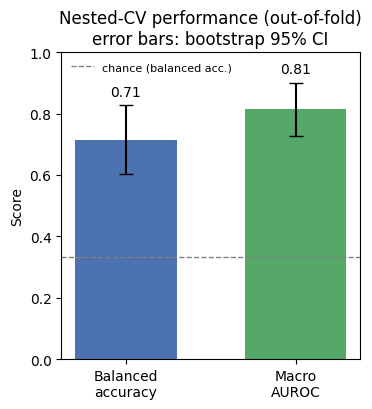

Balanced accuracy: 0.714 [0.595, 0.820] | macro AUROC (OOF): 0.814 [0.721, 0.895]


In [10]:
# Manuscript performance summary — pooled OOF metrics from nested CV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

bal_mean = float(outer_df["balanced_accuracy"].mean())
bal_sd = float(outer_df["balanced_accuracy"].std(ddof=1))
auroc_fold_sd = float(outer_df["macro_auroc"].std(ddof=1))

classes_sorted = np.unique(y_np)
y_bin_oof = label_binarize(y_np, classes=classes_sorted)
macro_auroc_oof = float(roc_auc_score(y_bin_oof, oof_pred, average="macro", multi_class="ovr"))
micro_auroc_oof = float(roc_auc_score(y_bin_oof, oof_pred, average="micro", multi_class="ovr"))

# Error bars: per-fold SD by default; bootstrap 95% CI half-width when enabled
bal_err = bal_sd
auroc_err = auroc_fold_sd
bal_ci_lo = bal_ci_hi = auroc_ci_lo = auroc_ci_hi = np.nan
uncertainty_method = "per_fold_sd"

if RUN_OOF_BOOTSTRAP_CI and oof_bootstrap_ci is not None:
    bal_row = oof_bootstrap_ci.loc[
        oof_bootstrap_ci["metric"] == "balanced_accuracy_oof"
    ].iloc[0]
    auroc_row = oof_bootstrap_ci.loc[
        oof_bootstrap_ci["metric"] == "macro_AUROC_oof"
    ].iloc[0]
    bal_ci_lo, bal_ci_hi = float(bal_row["ci_lo"]), float(bal_row["ci_hi"])
    auroc_ci_lo, auroc_ci_hi = float(auroc_row["ci_lo"]), float(auroc_row["ci_hi"])
    bal_err = (bal_ci_hi - bal_ci_lo) / 2
    auroc_err = (auroc_ci_hi - auroc_ci_lo) / 2
    uncertainty_method = "bootstrap_95ci_oof"

summary_rows = [
    {"metric": "balanced_accuracy_mean", "value": bal_mean, "uncertainty_method": uncertainty_method},
    {"metric": "balanced_accuracy_sd_per_fold", "value": bal_sd, "uncertainty_method": "per_fold_sd"},
    {"metric": "macro_AUROC_oof", "value": macro_auroc_oof, "uncertainty_method": uncertainty_method},
    {"metric": "macro_AUROC_sd_per_fold", "value": auroc_fold_sd, "uncertainty_method": "per_fold_sd"},
    {"metric": "micro_AUROC_oof", "value": micro_auroc_oof, "uncertainty_method": "pooled_oof"},
    {"metric": "n_patients", "value": len(y_np), "uncertainty_method": "count"},
    {"metric": "n_outer_folds", "value": len(outer_df), "uncertainty_method": "count"},
]
if np.isfinite(bal_ci_lo):
    summary_rows.extend([
        {"metric": "balanced_accuracy_ci_lo", "value": bal_ci_lo, "uncertainty_method": uncertainty_method},
        {"metric": "balanced_accuracy_ci_hi", "value": bal_ci_hi, "uncertainty_method": uncertainty_method},
        {"metric": "macro_AUROC_ci_lo", "value": auroc_ci_lo, "uncertainty_method": uncertainty_method},
        {"metric": "macro_AUROC_ci_hi", "value": auroc_ci_hi, "uncertainty_method": uncertainty_method},
    ])

summary = pd.DataFrame(summary_rows)
ELASTICNET_DIR = Path(FIG_DIR) / "elasticnet"
ELASTICNET_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(ELASTICNET_DIR / "nestedcv_performance_summary.csv", index=False)
display(summary)

fig, ax = plt.subplots(figsize=(3.8, 4.2))
labels = ["Balanced\naccuracy", "Macro\nAUROC"]
vals = [bal_mean, macro_auroc_oof]
errs = [bal_err, auroc_err]
ax.bar(labels, vals, yerr=errs, capsize=5, color=["#4C72B0", "#55A868"], width=0.6)
ax.axhline(1.0 / len(classes_sorted), ls="--", c="grey", lw=1, label="chance (balanced acc.)")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
err_label = "bootstrap 95% CI" if uncertainty_method == "bootstrap_95ci_oof" else "per-fold SD"
ax.set_title(f"Nested-CV performance (out-of-fold)\nerror bars: {err_label}")
for i, v in enumerate(vals):
    ax.text(i, min(v + errs[i] + 0.03, 0.97), f"{v:.2f}", ha="center", fontsize=10)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(ELASTICNET_DIR / "nestedcv_performance_summary.svg", bbox_inches="tight")
fig.savefig(ELASTICNET_DIR / "nestedcv_performance_summary.png", dpi=300, bbox_inches="tight")
plt.show()

if np.isfinite(bal_ci_lo):
    print(
        f"Balanced accuracy: {bal_mean:.3f} [{bal_ci_lo:.3f}, {bal_ci_hi:.3f}] | "
        f"macro AUROC (OOF): {macro_auroc_oof:.3f} [{auroc_ci_lo:.3f}, {auroc_ci_hi:.3f}]"
    )
else:
    print(
        f"Balanced accuracy: {bal_mean:.3f} +/- {bal_sd:.3f} (per-fold) | "
        f"macro AUROC (OOF): {macro_auroc_oof:.3f} +/- {auroc_fold_sd:.3f} (per-fold)"
    )


## Fig 5H — immune-archetype classifier confusion matrix

Nested cross-validation elastic-net classifier of `abundance_cluster_30` from bulk gene expression. Plots the aggregated out-of-fold confusion matrix.

Saved SVG → figures/fig5/elasticnet/confusion_elasticnet_cluster_assignment_named.svg


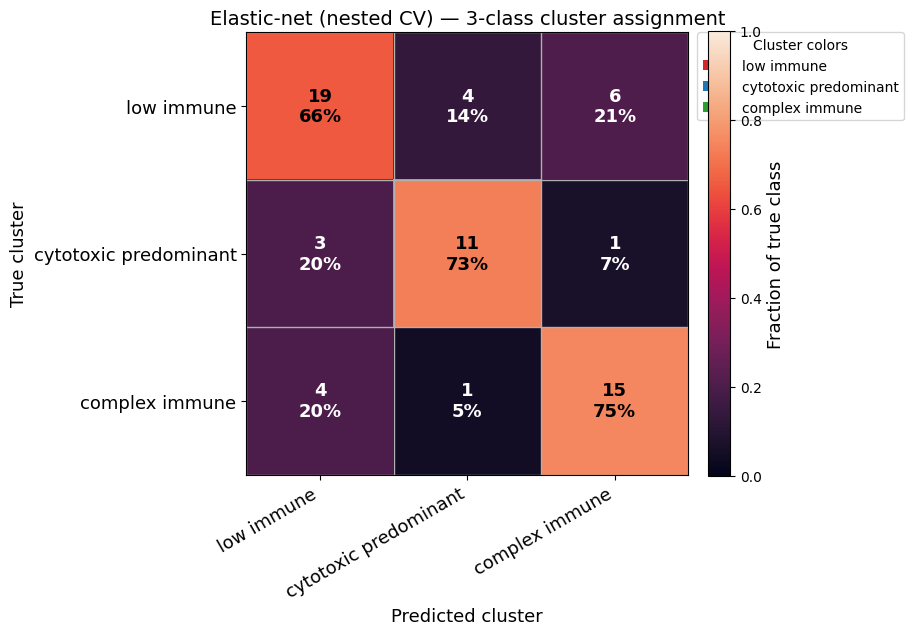

(<Figure size 840x680 with 2 Axes>,
 <Axes: title={'center': 'Elastic-net (nested CV) — 3-class cluster assignment'}, xlabel='Predicted cluster', ylabel='True cluster'>)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

ELASTICNET_DIR = Path(FIG_DIR) / "elasticnet"
ELASTICNET_DIR.mkdir(parents=True, exist_ok=True)
OUTDIR = ELASTICNET_DIR

# ------------------------------------------------------------------
# Your class-name mapping
# ------------------------------------------------------------------
cluster_name_map = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune",
}

# ------------------------------------------------------------------
# Colors keyed by DISPLAY NAME, not integer
# ------------------------------------------------------------------
CLASS_COLORS_NAMED = {
    "low immune": "#d62728",             # red
    "cytotoxic predominant": "#1f77b4", # blue
    "complex immune": "#2ca02c",        # green
}

def _normalize_label_value(x):
    """
    Convert labels like 1, '1', np.int32(1) consistently to string form.
    """
    try:
        # catches numpy ints too
        if pd.notna(x) and float(x).is_integer():
            return str(int(float(x)))
    except Exception:
        pass
    return str(x)

def _build_display_name_map(cluster_name_map):
    """
    Return mapping with stringified keys for robust lookup.
    """
    return {_normalize_label_value(k): str(v) for k, v in cluster_name_map.items()}

def _map_label_to_display(label, display_name_map):
    """
    Map raw label to a display name if available; otherwise keep raw label as string.
    """
    label_str = _normalize_label_value(label)
    return display_name_map.get(label_str, label_str)

def _build_class_color_map(display_labels, class_colors=None):
    """
    Return a color dict for display labels.
    Falls back to matplotlib tab10 if any label is missing.
    """
    display_labels = [str(c) for c in display_labels]
    class_colors = class_colors or {}

    fallback = plt.get_cmap("tab10")
    out = {}
    for i, c in enumerate(display_labels):
        out[c] = class_colors.get(c, fallback(i % 10))
    return out

def _rename_cm_df_with_display_names(cm_df, cluster_name_map):
    """
    Convert cm_df index/columns from true_1 / pred_2 etc. into display names.
    """
    display_name_map = _build_display_name_map(cluster_name_map)
    cm_df_named = cm_df.copy()

    new_index = []
    for idx in cm_df_named.index.astype(str):
        raw = idx.replace("true_", "")
        disp = _map_label_to_display(raw, display_name_map)
        new_index.append(f"true_{disp}")

    new_cols = []
    for col in cm_df_named.columns.astype(str):
        raw = col.replace("pred_", "")
        disp = _map_label_to_display(raw, display_name_map)
        new_cols.append(f"pred_{disp}")

    cm_df_named.index = new_index
    cm_df_named.columns = new_cols
    return cm_df_named

def plot_confusion_matrix_svg(
    cm_df=None,
    cm=None,
    class_names=None,
    cluster_name_map=None,
    title="Confusion matrix",
    normalize="true",   # "true", "pred", "all", or None
    show_counts=True,
    show_perc=True,
    figsize=(8.4, 6.8),
    outdir=None,
    filename="confusion_matrix.svg",
    cmap="YlOrRd",
    class_colors=None,
    legend_title="Cluster colors",
    xlabel="Predicted cluster",
    ylabel="True cluster",
    fontsize=13,
    annot_fontsize=13,
):
    """
    Plot confusion matrix with support for integer->name mapping.

    Accepts either:
      - cm_df with index true_* and columns pred_*
      - or raw cm + class_names

    If cluster_name_map is provided, labels are converted to display names.
    """

    if cm_df is None:
        if cm is None or class_names is None:
            raise ValueError("Provide either cm_df OR (cm and class_names).")

        if cluster_name_map is not None:
            display_name_map = _build_display_name_map(cluster_name_map)
            class_names_display = [
                _map_label_to_display(c, display_name_map) for c in class_names
            ]
        else:
            class_names_display = [_normalize_label_value(c) for c in class_names]

        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in class_names_display],
            columns=[f"pred_{c}" for c in class_names_display],
        )
    else:
        cm_df = cm_df.copy()
        if cluster_name_map is not None:
            cm_df = _rename_cm_df_with_display_names(cm_df, cluster_name_map)

    true_labels = [str(s).replace("true_", "") for s in cm_df.index.astype(str)]
    pred_labels = [str(s).replace("pred_", "") for s in cm_df.columns.astype(str)]
    cm_counts = cm_df.to_numpy(dtype=float)

    # normalize
    if normalize is None:
        cm_norm = None
    elif normalize == "true":
        denom = cm_counts.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm_counts, np.maximum(denom, 1e-12))
    elif normalize == "pred":
        denom = cm_counts.sum(axis=0, keepdims=True)
        cm_norm = np.divide(cm_counts, np.maximum(denom, 1e-12))
    elif normalize == "all":
        denom = cm_counts.sum()
        cm_norm = cm_counts / max(denom, 1e-12)
    else:
        raise ValueError("normalize must be one of: None, 'true', 'pred', 'all'")

    plot_mat = cm_norm if cm_norm is not None else cm_counts

    if cm_norm is not None:
        vmin, vmax = 0.0, 1.0
    else:
        vmax = float(np.nanmax(cm_counts)) if np.isfinite(cm_counts).any() else 1.0
        vmin = 0.0

    class_color_map = _build_class_color_map(true_labels, class_colors=class_colors)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(plot_mat, aspect="equal", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(pred_labels)))
    ax.set_yticks(np.arange(len(true_labels)))
    ax.set_xticklabels(pred_labels, rotation=30, ha="right", fontsize=fontsize)
    ax.set_yticklabels(true_labels, fontsize=fontsize)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1)

    # cell borders
    ax.set_xticks(np.arange(-0.5, len(pred_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(true_labels), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cm_norm is None:
        cbar.set_label("Count", fontsize=fontsize)
    else:
        cbar.set_label(
            "Fraction of true class" if normalize == "true"
            else "Fraction of predicted class" if normalize == "pred"
            else "Fraction of all samples",
            fontsize=fontsize
        )

    # annotations
    threshold = vmin + 0.55 * (vmax - vmin)
    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            parts = []
            if show_counts:
                parts.append(f"{int(cm_counts[i, j])}")
            if show_perc and cm_norm is not None:
                parts.append(f"{round(cm_norm[i, j] * 100):d}%")
            text = "\n".join(parts)
            if text:
                val = plot_mat[i, j]
                color = "black" if val > threshold else "white"
                ax.text(
                    j, i, text,
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=annot_fontsize,
                    fontweight="bold"
                )

    # legend
    legend_handles = [
        Patch(facecolor=class_color_map[lab], label=lab)
        for lab in true_labels
    ]
    if legend_handles:
        ax.legend(
            handles=legend_handles,
            title=legend_title,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0
        )

    plt.rcParams["svg.fonttype"] = "none"
    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outpath = outdir / filename
        fig.savefig(outpath, format="svg", bbox_inches="tight")
        print(f"Saved SVG → {rel_path(outpath, REPO_ROOT)}")

    plt.show()
    return fig, ax


# ------------------------------------------------------------------
# Example usage with your existing cm_df
# ------------------------------------------------------------------
plot_confusion_matrix_svg(
    cm_df=cm_df,
    cluster_name_map=cluster_name_map,
    title="Elastic-net (nested CV) — 3-class cluster assignment",
    normalize="true",
    outdir=OUTDIR,
    filename="confusion_elasticnet_cluster_assignment_named.svg",
    cmap="rocket",
    class_colors=CLASS_COLORS_NAMED,
    legend_title="Cluster colors",
    xlabel="Predicted cluster",
    ylabel="True cluster",
)


## Figs 1F / 2F — Kaplan–Meier (OS, 5-year)
KM by anatomical location (`disease_type`) and by predicted immune archetype, using publication KM styling (censor ticks, at-risk table, log-rank annotations).

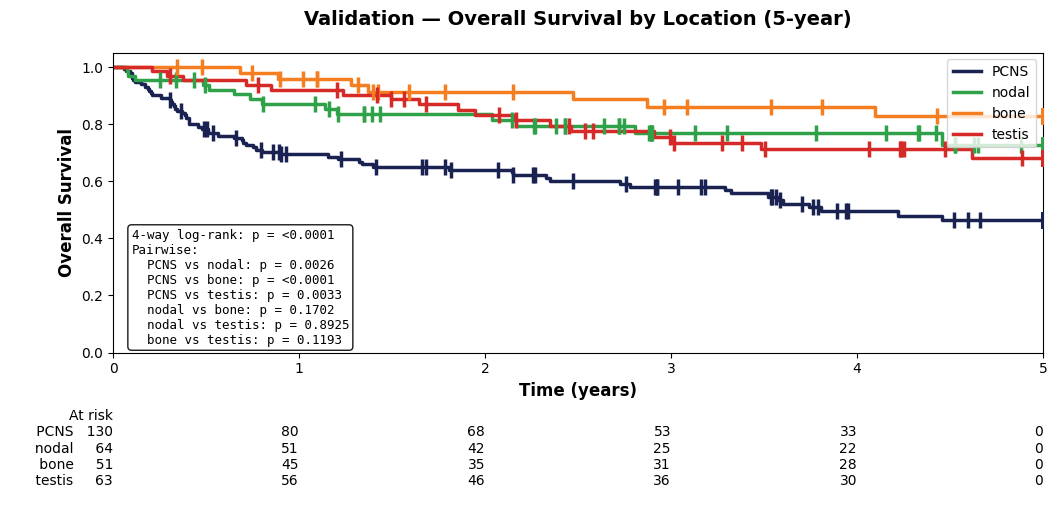

,group,n,events,global_logrank_p
0,PCNS,130,60,0.000007
1,nodal,64,14,0.000007
2,bone,51,7,0.000007
3,testis,63,17,0.000007


Wrote figures/fig5/figS5A_val_km_os_location.svg
Saved: data/supplementary/fig5/figS5A_val_km_os_location.csv


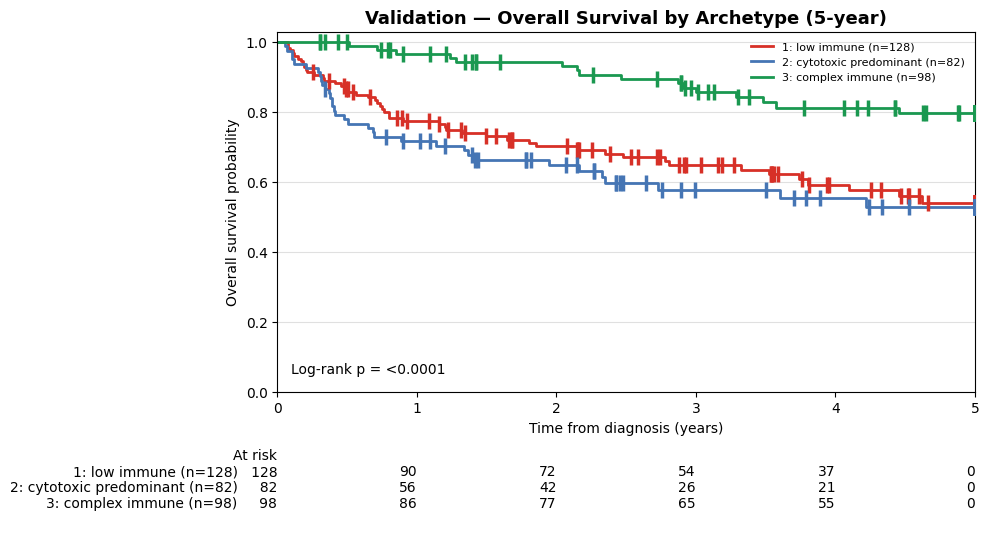

,archetype_id,archetype,n,events,global_logrank_p
0,1,low immune,128,48,0.000032
1,2,cytotoxic predominant,82,34,0.000032
2,3,complex immune,98,16,0.000032


Wrote figures/fig5/fig5A_val_km_os_archetype.svg
Saved: data/supplementary/fig5/fig5A_val_km_os_archetype.csv


In [12]:
loc_os = vf.plot_km_by_location(
    surv,
    title="Validation — Overall Survival by Location (5-year)",
    ylabel="Overall Survival",
    out_path=FIG_DIR / "figS5A_val_km_os_location.svg",
)
display(loc_os)
loc_os.to_csv(FIG_DIR / "figS5A_val_km_os_location_summary.csv", index=False)
log_wrote(FIG_DIR / "figS5A_val_km_os_location.svg", REPO_ROOT)
log_saved(write_supplementary_table(loc_os, REPO_ROOT, "figS5A_val_km_os_location"), REPO_ROOT)

arch_os = vf.plot_km_by_archetype(
    surv,
    title="Validation — Overall Survival by Archetype (5-year)",
    ylabel="Overall survival probability",
    out_path=FIG_DIR / "fig5A_val_km_os_archetype.svg",
)
display(arch_os)
arch_os.to_csv(FIG_DIR / "fig5A_val_km_os_archetype_summary.csv", index=False)
log_wrote(FIG_DIR / "fig5A_val_km_os_archetype.svg", REPO_ROOT)
log_saved(write_supplementary_table(arch_os, REPO_ROOT, "fig5A_val_km_os_archetype"), REPO_ROOT)


## Validation — location × predicted immune archetype (S2C analogue)
Three heatmaps mirroring discovery **Fig S2C** (discovery Fig S2C): raw counts, row-normalized proportions (count + row % annotation), and standardized residuals from a global chi-square test. Per-location pie charts show predicted immune archetype composition within each anatomical site (validation analogue to discovery **Fig 2F** location pies).

=== Location × predicted immune archetype (counts) ===


Archetype,low immune,cytotoxic predominant,complex immune
Location,,,
PCNS,74,45,11
bone,9,8,34
nodal,21,12,31
testis,24,17,22



=== Row-normalized proportions ===


Archetype,low immune,cytotoxic predominant,complex immune
Location,,,
PCNS,0.569,0.346,0.085
bone,0.176,0.157,0.667
nodal,0.328,0.188,0.484
testis,0.381,0.270,0.349



=== Chi-square ===


,chi2,p_value,dof,cramers_v,low_expected_cells_lt5
0,70.164919,3.782484e-13,6,0.337497,0



=== Enrichment / depletion (|residual| ≥ 1) ===
Enriched: PCNS × low immune (residual=2.72)
Enriched: PCNS × cytotoxic predominant (residual=1.77)
Depleted: PCNS × complex immune (residual=-4.72)
Depleted: bone × low immune (residual=-2.65)
Depleted: bone × cytotoxic predominant (residual=-1.51)
Enriched: bone × complex immune (residual=4.41)
Depleted: nodal × low immune (residual=-1.09)
Depleted: nodal × cytotoxic predominant (residual=-1.22)
Enriched: nodal × complex immune (residual=2.36)


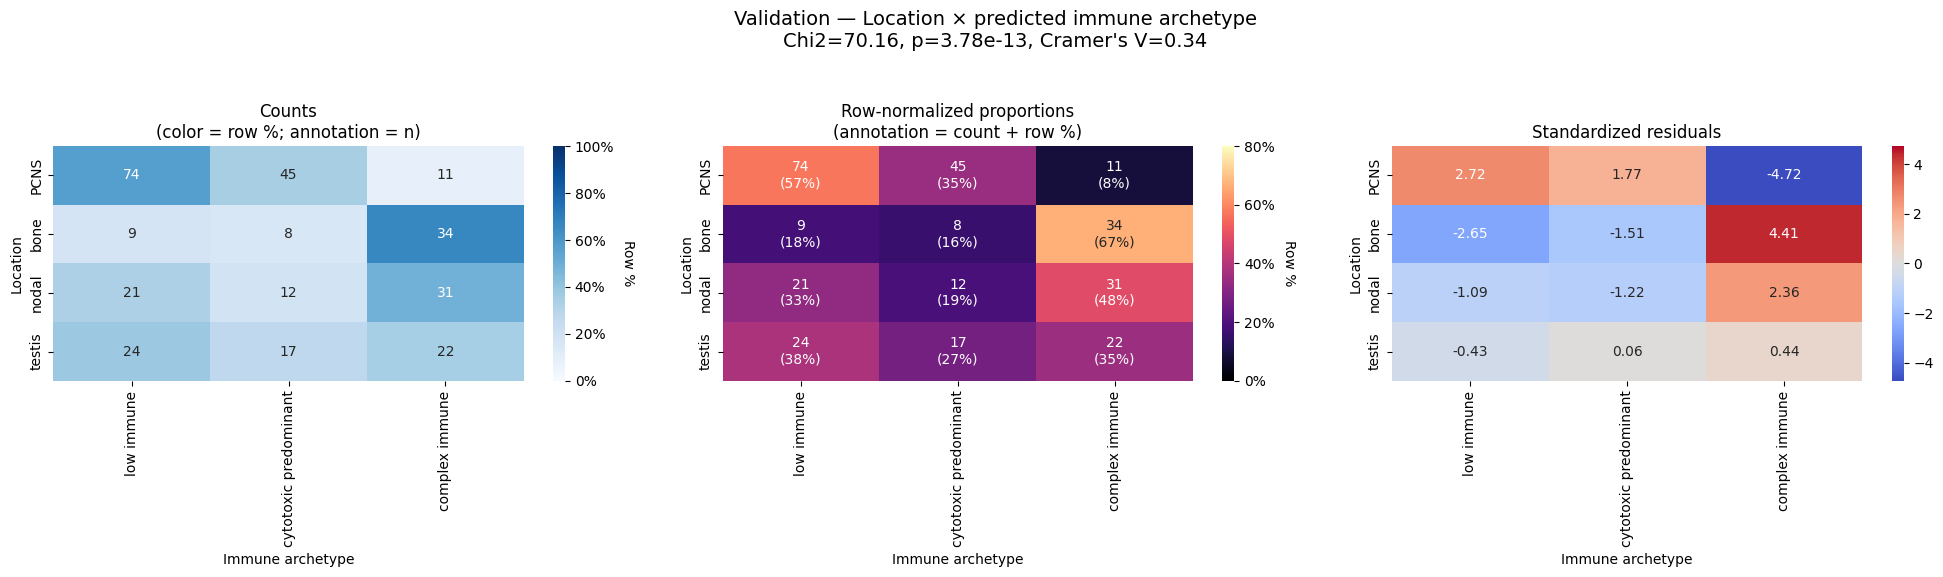

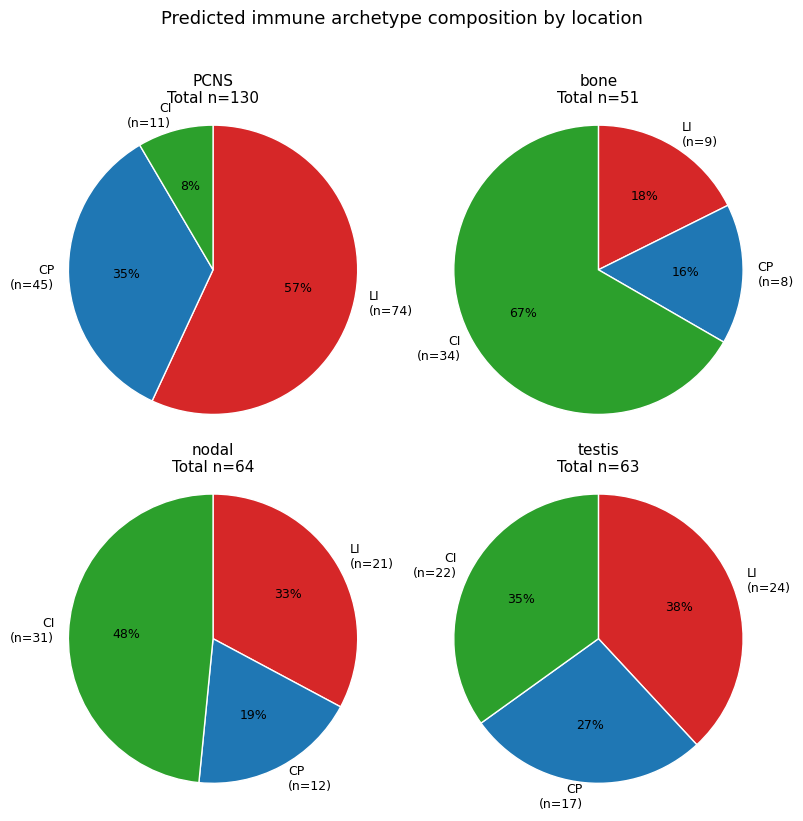

Wrote figures/fig5/location_archetype_distribution/val_location_archetype_heatmaps.svg
Wrote figures/fig5/location_archetype_distribution/val_location_archetype_pies.svg
Wrote figures/fig5/fig5F_val_location_archetype_heatmaps.svg
Wrote figures/fig5/fig5F_val_location_archetype_heatmaps.png
Wrote figures/fig5/fig5F_val_location_archetype_pies.svg
Wrote figures/fig5/fig5F_val_location_archetype_pies.png
Saved: data/supplementary/fig5/fig5F_location_archetype_counts.csv
Saved: data/supplementary/fig5/fig5F_location_archetype_row_props.csv
Saved: data/supplementary/fig5/fig5F_location_archetype_residuals.csv
Saved: data/supplementary/fig5/fig5F_location_archetype_chi2_stats.csv


In [13]:
from dlbcl.location_archetype_distribution import (
    build_location_archetype_frame,
    compute_location_archetype_association,
    association_stats_table,
    save_location_archetype_distribution,
)

LOC_ARCH_OUT = FIG_DIR / "location_archetype_distribution"
loc_arch_df = build_location_archetype_frame(pred)
loc_arch_assoc = compute_location_archetype_association(loc_arch_df)

print("=== Location × predicted immune archetype (counts) ===")
display(loc_arch_assoc.counts)
print("\n=== Row-normalized proportions ===")
display(loc_arch_assoc.row_props.round(3))
print("\n=== Chi-square ===")
display(association_stats_table(loc_arch_assoc))
if loc_arch_assoc.low_expected_cells:
    print(f"Warning: {loc_arch_assoc.low_expected_cells} cells have expected count < 5.")
print("\n=== Enrichment / depletion (|residual| ≥ 1) ===")
if loc_arch_assoc.enrichment_summary:
    for line in loc_arch_assoc.enrichment_summary:
        print(line)
else:
    print("No cells with |standardized residual| ≥ 1.")

loc_arch_paths = save_location_archetype_distribution(
    pred, LOC_ARCH_OUT, prefix="val", show=True,
)
log_wrote(loc_arch_paths["heatmap"], REPO_ROOT)
log_wrote(loc_arch_paths["pies"], REPO_ROOT)

# Paper panels at figures/fig5/ root (SVG + PNG).
from dlbcl.dlbcl_io import promote_panel
for written in promote_panel(
    loc_arch_paths["heatmap"], FIG_DIR / "fig5F_val_location_archetype_heatmaps"
):
    log_wrote(written, REPO_ROOT)
for written in promote_panel(
    loc_arch_paths["pies"], FIG_DIR / "fig5F_val_location_archetype_pies"
):
    log_wrote(written, REPO_ROOT)
log_saved(write_supplementary_table(loc_arch_assoc.counts.reset_index(), REPO_ROOT, "fig5F_location_archetype_counts"), REPO_ROOT)
log_saved(write_supplementary_table(loc_arch_assoc.row_props.reset_index(), REPO_ROOT, "fig5F_location_archetype_row_props"), REPO_ROOT)
log_saved(write_supplementary_table(loc_arch_assoc.residuals.reset_index(), REPO_ROOT, "fig5F_location_archetype_residuals"), REPO_ROOT)
log_saved(write_supplementary_table(association_stats_table(loc_arch_assoc), REPO_ROOT, "fig5F_location_archetype_chi2_stats"), REPO_ROOT)


## Figs S3A–S3D — Cox models (OS, mirroring discovery Cox models (Fig S3A–D))
Univariable Cox for Sex, Location, Archetype, and Hans COO (levels with no patients are omitted). Multivariable Location + Archetype forest, 2-year landmark event-rate grid with symmetric likelihood-ratio tests, and prognostic information partition.

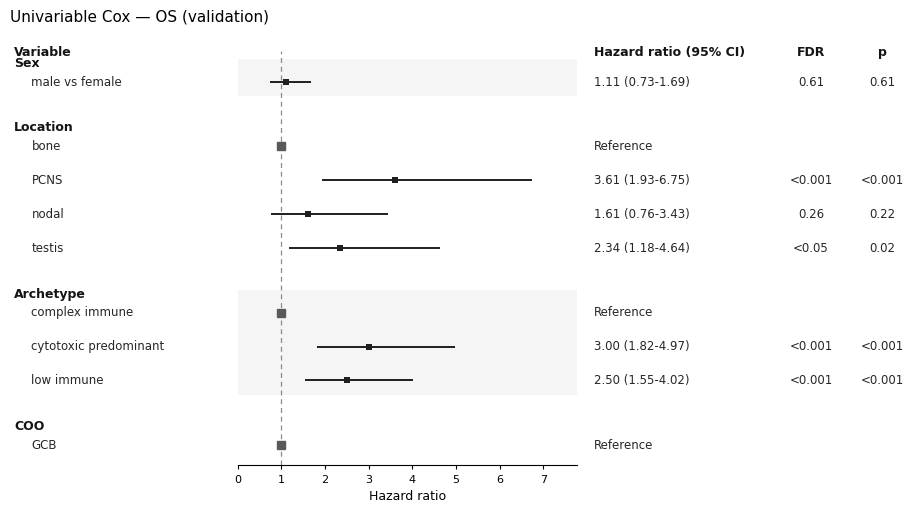

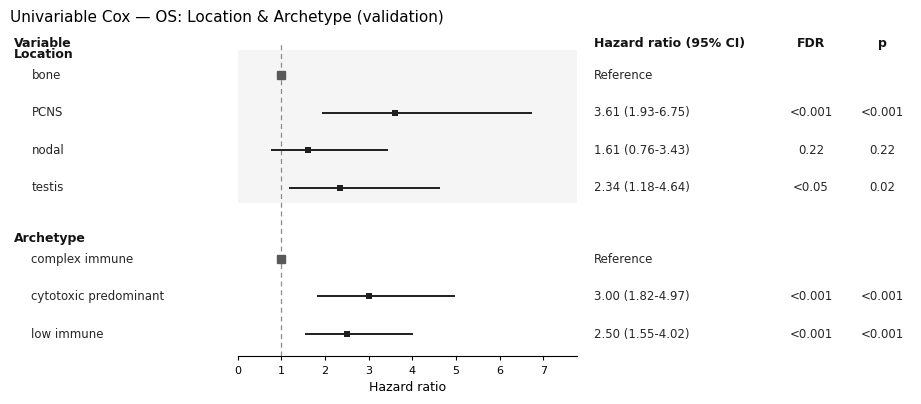

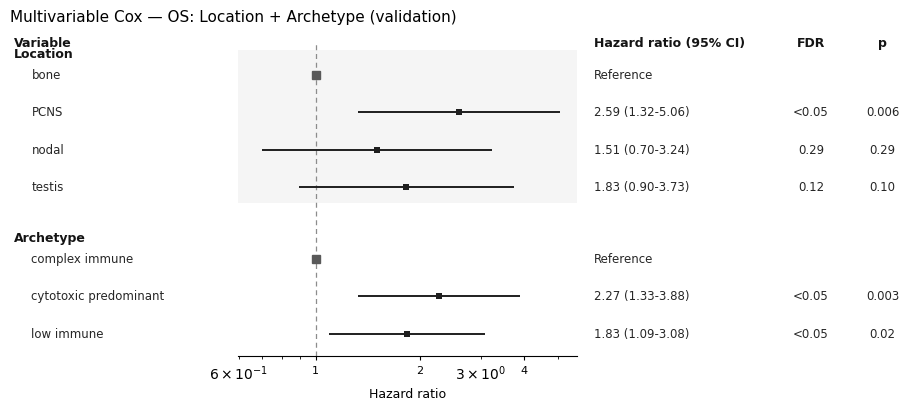

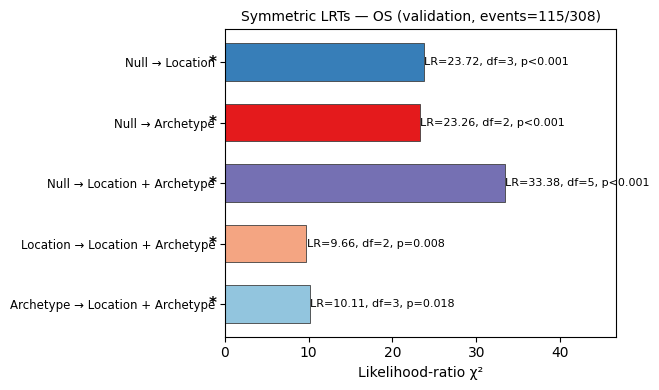

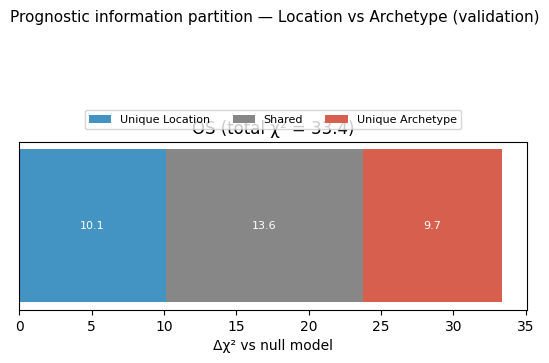

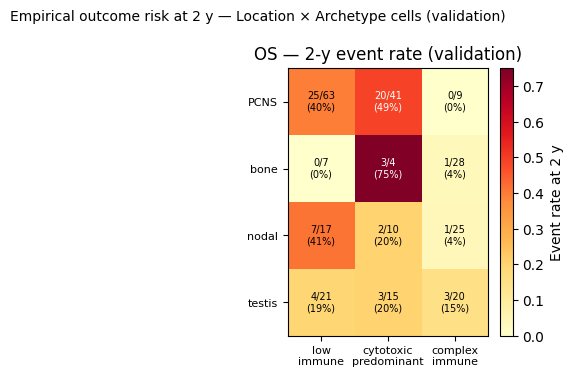

Saved: data/supplementary/fig5/fig5_supp_cox_univar_OS.csv
Saved: data/supplementary/fig5/fig5G_cox_location_archetype_forest_OS.csv
Saved: data/supplementary/fig5/fig5I_symmetric_lrt.csv
Saved: data/supplementary/fig5/fig5J_loglikelihood_partition.csv
Saved: data/supplementary/fig5/fig5H_event_rate_grid.csv
Cox cohort: n=308 | OS events=115
Outputs → figures/fig5/cox_validation


,endpoint,factor,term,n_patients,n_events,HR,CI_lower,CI_upper,coef,p
4,OS,Archetype,Archetype_cytotoxic predominant,308,115,3.004636,1.817993,4.965826,1.100156,0.000018
5,OS,Archetype,Archetype_low immune,308,115,2.499833,1.552965,4.024021,0.916224,0.000162
6,OS,COO,COO_GCB,261,95,0.424454,0.262207,0.687093,-0.856952,0.000488
1,OS,Location,Location_PCNS,308,115,3.610271,1.931557,6.747955,1.283783,0.000057
3,OS,Location,Location_testis,308,115,2.338300,1.179344,4.636179,0.849424,0.015002
2,OS,Location,Location_nodal,308,115,1.612652,0.757618,3.432660,0.477880,0.215043
0,OS,Sex,Sex,308,115,1.113190,0.734742,1.686568,0.107230,0.612957


,endpoint,chi2_total,chi2_unique_location,chi2_unique_archetype,chi2_shared_raw,chi2_shared,shared_suppression
0,OS,33.378396,10.114507,9.65646,13.60743,13.60743,False


Wrote figures/fig5/fig5G_cox_location_archetype_forest_OS.svg
Wrote figures/fig5/fig5G_cox_location_archetype_forest_OS.png
Wrote figures/fig5/fig5H_event_rate_grid.svg
Wrote figures/fig5/fig5H_event_rate_grid.png
Wrote figures/fig5/fig5I_symmetric_lrt.svg
Wrote figures/fig5/fig5I_symmetric_lrt.png
Wrote figures/fig5/fig5J_loglikelihood_partition.svg
Wrote figures/fig5/fig5J_loglikelihood_partition.png


In [14]:
import dlbcl.validation_cox as vc
from dlbcl.dlbcl_io import promote_panel

COX_DIR = Path(FIG_DIR) / "cox_validation"
cox_results = vc.run_validation_cox_suite(
    pred,
    COX_DIR,
    repo_root=REPO_ROOT,
    write_supplementary=True,
    show=True,
)
cox_surv = cox_results["surv"]
print(
    f"Cox cohort: n={cox_results['n_patients']} | OS events={cox_results['n_events']}\n"
    f"Outputs → {rel_path(COX_DIR, REPO_ROOT)}"
)
display(cox_results["univariable"].head(12))
display(cox_results["partition"])

# Paper panels at figures/fig5/ root.
_cox_promote = {
    "cox_multivariable_location_archetype_forest_OS": "fig5G_cox_location_archetype_forest_OS",
    "location_archetype_event_rate_grid": "fig5H_event_rate_grid",
    "cox_location_archetype_symmetric_lrt_OS": "fig5I_symmetric_lrt",
    "cox_loglikelihood_partition": "fig5J_loglikelihood_partition",
}
for src_stem, dest_stem in _cox_promote.items():
    for written in promote_panel(COX_DIR / src_stem, FIG_DIR / dest_stem):
        log_wrote(written, REPO_ROOT)


## Additional analysis — classifier OS benchmark
Head-to-head comparison of molecular / immune classifiers for **incremental OS prognostic value** in the external validation cohort.
| Tier | Metric |
|------|--------|
| **Primary** | Adjusted incremental LRT χ² (classifier added to clinical baseline) |
| **Secondary** | Bootstrap ΔC-index (full Cox − baseline Cox) |
| **Tertiary** | ΔAIC / ΔBIC, n_levels, % missing, EPV |
**Baseline (default):** Sex + Location. Age, Ann Arbor stage, and IPI are added automatically when those columns appear in the validation metadata.
**Classifiers:** GEP-based panel (all patients) and genomic panel (patients with `genomic_tested`, when labels are present). EcoTyper **confident** and **best match** are evaluated separately.
**Data:** `adata.uns['validation_cohort']` → predictions + `case_classification_validation`.

## Incremental OS benchmark
Fits nested Cox models per classifier (lifelines, `penalizer=0.01`). LRT FDR is Benjamini–Hochberg **within** GEP and genomic panels separately.

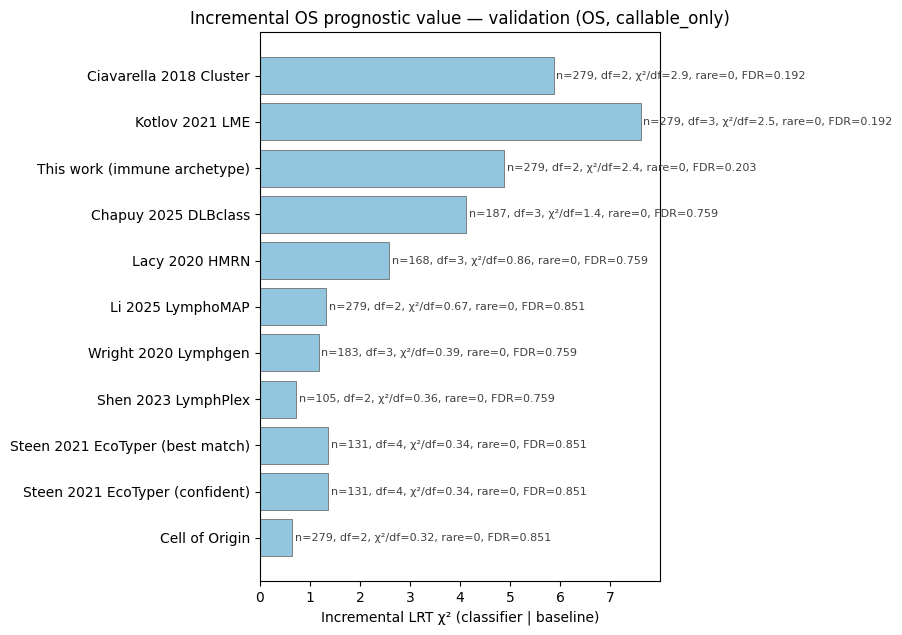

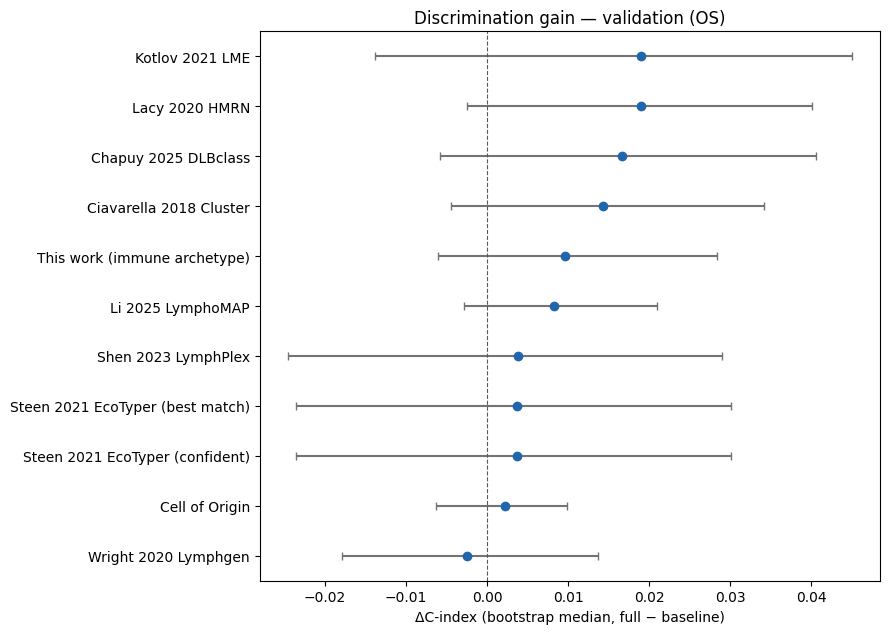

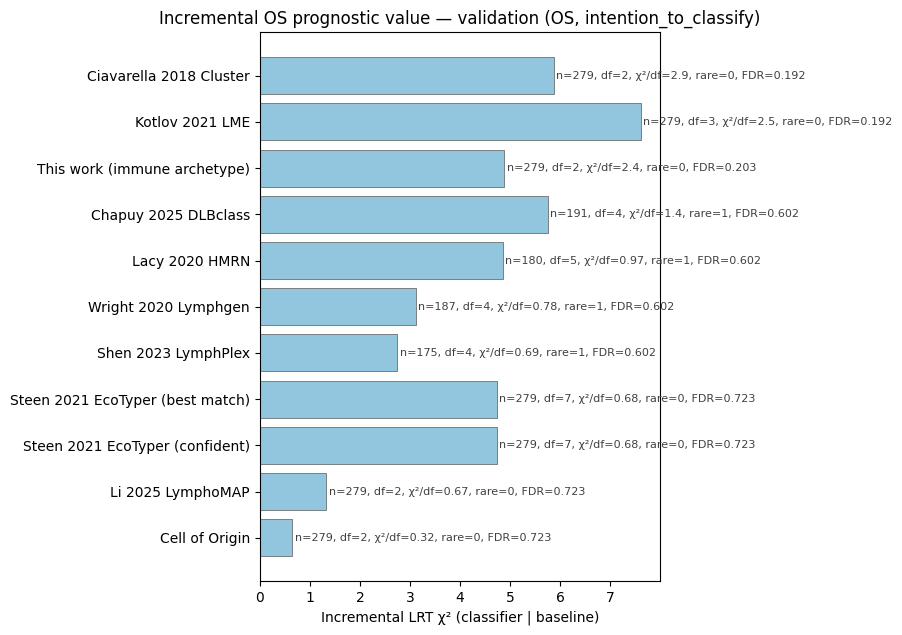

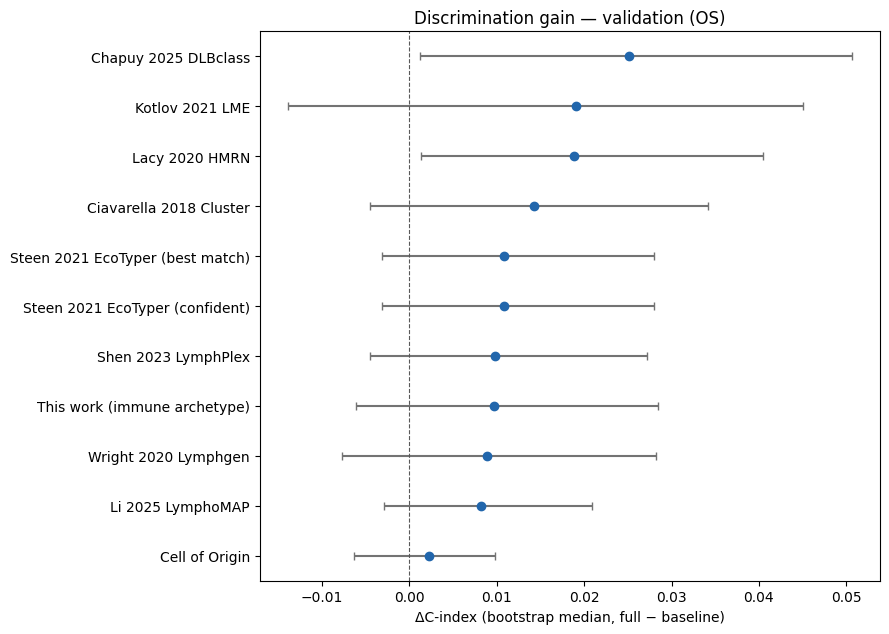

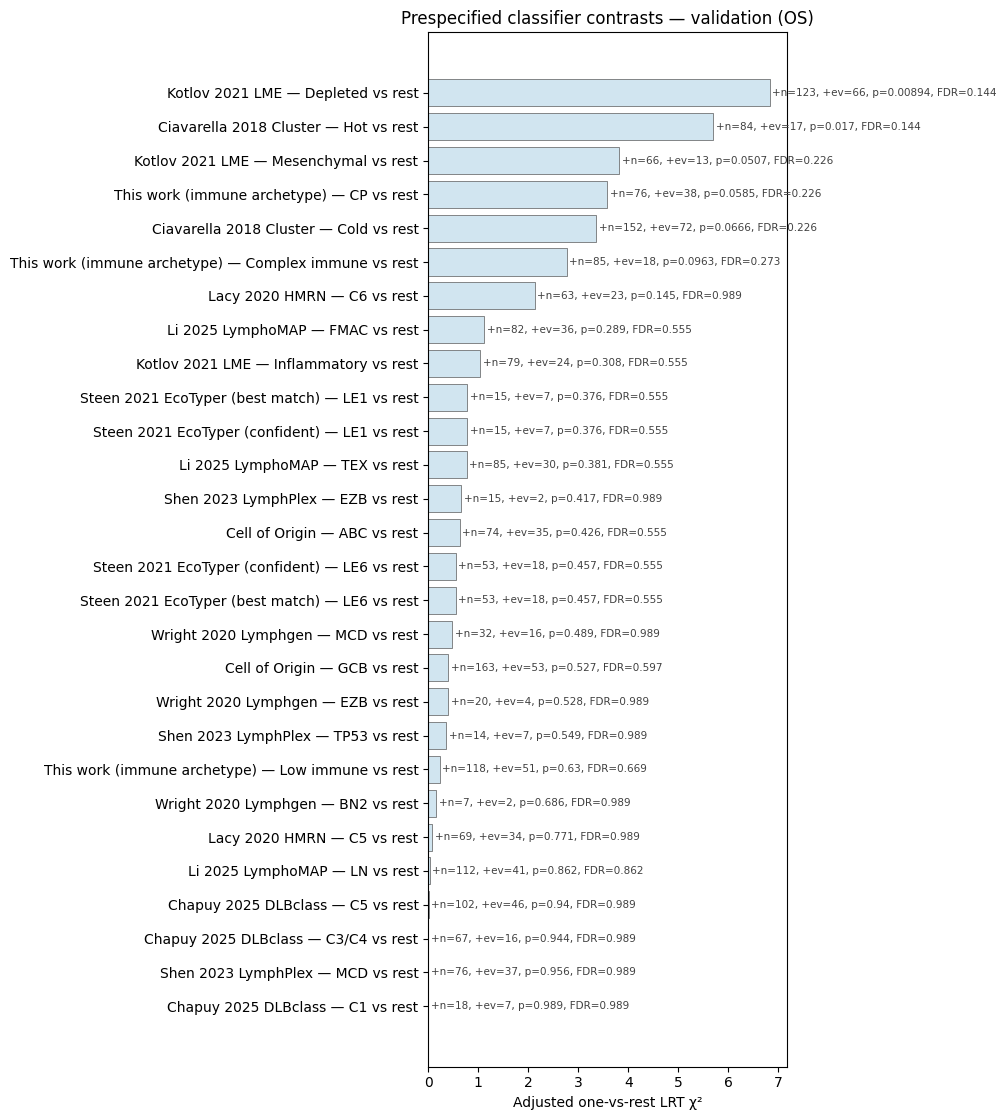

Baseline covariates: Sex, Location, Age, IPI_score


,endpoint,classifier,column,panel,analysis_type,analysis_mode,contrast,status,skip_reason,baseline_covariates,...,delta_aic,bic_baseline,bic_full,delta_bic,delta_cindex_boot_median,delta_cindex_boot_ci_lower,delta_cindex_boot_ci_upper,n_ecotype_imputed,pct_ecotype_imputed,lr_fdr
0,OS,Chapuy 2025 DLBclass,DLBclass,genomic,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,1.875207,637.512646,649.081179,11.568533,0.016606,-0.005863,0.040581,NaN,NaN,0.758612
1,OS,Lacy 2020 HMRN,HMRN,genomic,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,3.416446,609.204837,621.993175,12.788338,0.018929,-0.002424,0.040079,NaN,NaN,0.758612
2,OS,Shen 2023 LymphPlex,LymphPlex,genomic,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,3.276196,386.210430,394.794547,8.584117,0.003879,-0.024547,0.028955,NaN,NaN,0.758612
3,OS,Wright 2020 Lymphgen,Lymphgen,genomic,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,4.823359,643.687954,658.139772,14.451818,-0.002412,-0.017852,0.013633,NaN,NaN,0.758612
4,OS,Ciavarella 2018 Cluster,Ciav_Cluster,gep,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,-1.866908,1054.533995,1059.929510,5.395515,0.014294,-0.004475,0.034122,NaN,NaN,0.192322
5,OS,Kotlov 2021 LME,KotlovSig,gep,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,-1.603854,1054.533995,1063.823776,9.289782,0.019031,-0.013880,0.044990,NaN,NaN,0.192322
6,OS,This work (immune archetype),abundance_cluster_30_label,gep,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,-0.880302,1054.533995,1060.916116,6.382121,0.009642,-0.006048,0.028403,NaN,NaN,0.203345
7,OS,Li 2025 LymphoMAP,lymphomap,gep,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,2.669496,1054.533995,1064.465914,9.931919,0.008222,-0.002878,0.020900,NaN,NaN,0.850584
8,OS,Cell of Origin,COO_NanoString,gep,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,3.351173,1054.533995,1065.147591,10.613597,0.002273,-0.006337,0.009817,NaN,NaN,0.850584
9,OS,Steen 2021 EcoTyper (confident),Lymphoma_Ecotype_confident,gep,global,callable_only,,ok,,"Sex, Location, Age, IPI_score",...,6.636912,411.833918,429.971619,18.137701,0.003678,-0.023586,0.030105,NaN,NaN,0.850584


Wrote figures/fig5/classifier_os_benchmark/figVal16_incremental_lrt.svg
Wrote figures/fig5/classifier_os_benchmark/figVal16_delta_cindex_bootstrap.svg
Saved: data/supplementary/fig5/figS5_supp_classifier_os_benchmark.csv
Saved: figures/fig5/classifier_os_benchmark/classifier_os_benchmark.csv


In [15]:
N_BOOT = 300  # bootstrap replicates for ΔC-index CI

BENCH_DIR = Path(FIG_DIR) / "classifier_os_benchmark"
BENCH_DIR.mkdir(parents=True, exist_ok=True)

results = run_classifier_os_benchmark(
    pred,
    case_cc,
    BENCH_DIR,
    n_boot=N_BOOT,
    show=True,
)

baseline_used = results.loc[results["status"] == "ok", "baseline_covariates"].iloc[0] if (results["status"] == "ok").any() else ", ".join(BASELINE_CORE)
print(f"Baseline covariates: {baseline_used}")
display(results)

FIG_LRT = BENCH_DIR / "figVal16_incremental_lrt.svg"
FIG_DC = BENCH_DIR / "figVal16_delta_cindex_bootstrap.svg"
log_wrote(FIG_LRT, REPO_ROOT)
log_wrote(FIG_DC, REPO_ROOT)
log_saved(write_supplementary_table(results, REPO_ROOT, "figS5_supp_classifier_os_benchmark"), REPO_ROOT)
log_saved(BENCH_DIR / "classifier_os_benchmark.csv", REPO_ROOT)
